/usr/local/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | net     | Sequential       | 2.4 M  | train
1 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
2.4 M     Trainable params
0         Non-trainable params
2.4 M     Total params
9.543     Total estimated model params size (MB)
30        Modul

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=12` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.766865074634552     │
│         test_loss         │    2.1517605781555176     │
└───────────────────────────┴───────────────────────────┘

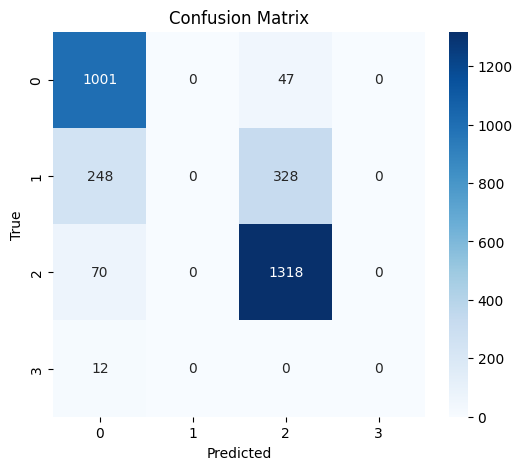

KeyError: "['train_loss'] not in index"

In [3]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset, WeightedRandomSampler
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF

import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Configs
# =========================
DATA_ROOT = "../../fiot_highway2-main/data/"
BOOSTED_CLASS1_ROOT = "./BoostedClass1"
BOOSTED_CLASS3_ROOT = "./BoostedClass3"
TRAIN_TXT = "../../fiot_highway2-main/train.txt"
TEST_TXT  = "../../fiot_highway2-main/test.txt"

MIN_LABEL = 0
MAX_LABEL = 3
RESIZE_TO = (64, 64)
BATCH_SIZE = 32
LR = 1e-3
MAX_EPOCHS = 12
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Classes to augment with SpecAugment 
SPEC_AUGMENT_CLASSES = {1, 3}

# MixUp oversampling multiples
MIXUP_OVERSAMPLE = {
    3: 10,   # Expand class 3 by 10x with MixUp
    1: 3     # Expand class 1 by 3x with MixUp
}

# =========================
# Spectrogram & Amplitude to dB equivalents (manual implementations)
# =========================
def spectrogram(x, n_fft=1024, hop_length=512, power=2.0):
    if x.dim() == 3:
        x = x.view(1, -1)
    window = torch.hann_window(n_fft, device=x.device)
    spec = torch.stft(x.squeeze(0), n_fft=n_fft, hop_length=hop_length, window=window, return_complex=True)
    spec_power = spec.abs() ** power
    return spec_power.unsqueeze(0)

def amplitude_to_db(x, amin=1e-10, top_db=80.0):
    # Convert amplitude to decibels (log scale)
    # x assumed to be power spectrogram (non-negative)
    x = x.clamp(min=amin)
    ref = x.max()
    log_spec = 10.0 * torch.log10(x)
    log_spec -= 10.0 * torch.log10(ref)
    log_spec = torch.clamp(log_spec, min=-top_db)
    return log_spec

# =========================
# Dataset class with optional SpecAugment for classes 1 and 3
# =========================
class HighwayDataset(Dataset):
    def __init__(self, paths, labels, root, resize=RESIZE_TO, apply_aug=False):
        self.paths = paths
        self.labels = labels
        self.root = root
        self.resize = resize
        self.apply_aug = apply_aug

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        fname = os.path.join(self.root, self.paths[idx] + ".npy")
        arr = np.load(fname).astype(np.float32)  # raw data, shape (H, W) or (length,)
        x = torch.from_numpy(arr)
        
        # Ensure input is 1D for spectrogram; if 2D, flatten or handle accordingly
        if x.dim() == 2:
            x = x.flatten()
        x = x.unsqueeze(0)  # (1, length)

        # Compute spectrogram manually
        x = spectrogram(x, n_fft=1024, hop_length=512, power=2.0)
        x = amplitude_to_db(x)
        x = TF.resize(x, self.resize)

        label = int(self.labels[idx])

        # SpecAugment manual implementation (simple masking)
        if self.apply_aug and (label in SPEC_AUGMENT_CLASSES):
            if np.random.rand() < 0.5:
                # Time masking: mask random time frames
                time_dim = x.shape[-1]
                t = np.random.randint(1, min(20, time_dim))
                t0 = np.random.randint(0, time_dim - t)
                x[:, :, t0:t0+t] = x.min()
            if np.random.rand() < 0.5:
                # Frequency masking: mask random freq bins
                freq_dim = x.shape[-2]
                f = np.random.randint(1, min(12, freq_dim))
                f0 = np.random.randint(0, freq_dim - f)
                x[:, f0:f0+f, :] = x.min()

        return x, label

# =========================
# Utility to extract file paths + labels from txt
# =========================
def extract_paths_labels(struct):
    paths = []
    labels = []
    for entry in struct:
        path = entry[0].split('/')[1].split('.')[0]
        label = int(entry[1])
        if MIN_LABEL <= label <= MAX_LABEL:
            paths.append(path)
            labels.append(label)
    return paths, labels

# =========================
# Load train/test structs
# =========================
all_train_struct = np.loadtxt(TRAIN_TXT, dtype=str).tolist()
all_test_struct = np.loadtxt(TEST_TXT, dtype=str).tolist()

train_paths, train_labels = extract_paths_labels(all_train_struct)
test_paths, test_labels = extract_paths_labels(all_test_struct)

# # Uncomment and implement boosted data loading if you have these files
# def boosted_struct_extract(boosted_folder, target_label):
#     files = [f[:-4] for f in os.listdir(boosted_folder) if f.endswith('.npy')]
#     return files, [target_label] * len(files)

# boosted1_paths, boosted1_labels = boosted_struct_extract(BOOSTED_CLASS1_ROOT, 1)
# boosted3_paths, boosted3_labels = boosted_struct_extract(BOOSTED_CLASS3_ROOT, 3)

# =========================
# Build datasets
# =========================
train_main_ds = HighwayDataset(train_paths, train_labels, DATA_ROOT, apply_aug=True)
# boosted1_ds = HighwayDataset(boosted1_paths, boosted1_labels, BOOSTED_CLASS1_ROOT, apply_aug=True)
# boosted3_ds = HighwayDataset(boosted3_paths, boosted3_labels, BOOSTED_CLASS3_ROOT, apply_aug=True)

# merged_train_ds = ConcatDataset([train_main_ds, boosted1_ds, boosted3_ds])
merged_train_ds = ConcatDataset([train_main_ds])
test_ds = HighwayDataset(test_paths, test_labels, DATA_ROOT, apply_aug=False)  # No augmentation for test

# =========================
# Compute class weights for CrossEntropyLoss
# =========================
# If you don't have boosted data, skip it here
all_train_labels = train_labels  # + boosted1_labels + boosted3_labels
class_weights_np = compute_class_weight('balanced', classes=np.arange(MIN_LABEL, MAX_LABEL+1), y=all_train_labels)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)

# =========================
# Weighted sampler for balancing classes in training
# =========================
label_counts = np.bincount(all_train_labels)
sample_weights = 1.0 / torch.tensor(label_counts, dtype=torch.float)[all_train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# =========================
# MixUp oversampling: create synthetic dataset expanding classes with MixUp
# =========================
class MixUpOversampleDataset(Dataset):
    def __init__(self, base_dataset, mixup_classes=MIXUP_OVERSAMPLE):
        self.base_ds = base_dataset
        self.mixup_classes = mixup_classes

        self.class_indices = {c: [] for c in range(MIN_LABEL, MAX_LABEL+1)}
        for idx in range(len(base_dataset)):
            _, label = base_dataset[idx]
            self.class_indices[label].append(idx)

        self.lengths = []
        for c in range(MIN_LABEL, MAX_LABEL+1):
            base_len = len(self.class_indices[c])
            multiplier = self.mixup_classes.get(c, 1)
            self.lengths.append(base_len * multiplier)
        self.total_length = sum(self.lengths)

        self.cumsum_lengths = np.cumsum([0] + self.lengths)

    def __len__(self):
        return self.total_length

    def __getitem__(self, idx):
        cls = None
        for c in range(MIN_LABEL, MAX_LABEL+1):
            if self.cumsum_lengths[c] <= idx < self.cumsum_lengths[c+1]:
                cls = c
                break
        if cls is None:
            raise IndexError("Index out of range in MixUpOversampleDataset")

        local_idx = idx - self.cumsum_lengths[cls]
        base_indices = self.class_indices[cls]

        base_len = len(base_indices)
        multiplier = self.mixup_classes.get(cls, 1)

        if multiplier == 1:
            return self.base_ds[base_indices[local_idx % base_len]]

        idx1 = base_indices[local_idx % base_len]
        idx2 = base_indices[np.random.randint(base_len)]

        x1, y1 = self.base_ds[idx1]
        x2, y2 = self.base_ds[idx2]

        lam = np.random.beta(0.3, 0.3)
        x_mix = lam * x1 + (1 - lam) * x2
        y_mix = y1 if lam >= 0.5 else y2

        return x_mix, y_mix

# Create the expanded training dataset with mixup oversampling
mixup_train_ds = MixUpOversampleDataset(merged_train_ds, mixup_classes=MIXUP_OVERSAMPLE)

train_loader = DataLoader(
    mixup_train_ds,
    batch_size=BATCH_SIZE,
    sampler=None,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# =========================
# CNN model with stride=1
# =========================
class DeepCNN(pl.LightningModule):
    def __init__(self, num_classes=MAX_LABEL-MIN_LABEL+1, lr=LR, class_weights=None):
        super().__init__()
        self.lr = lr
        self.class_weights = class_weights

        def conv_block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(cout),
                nn.ReLU(),
                nn.Conv2d(cout, cout, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(cout),
                nn.ReLU(),
                nn.MaxPool2d(2)
            )

        self.net = nn.Sequential(
            conv_block(1, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

        self.loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log('train_loss', loss, on_step=True, on_epoch=True)
        self.log('train_acc', acc, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log('test_loss', loss)
        self.log('test_acc', acc)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

# =========================
# Train the model
# =========================
logger = CSVLogger("logs", name="deep_cnn_highway")

model = DeepCNN(class_weights=class_weights).to(DEVICE)

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    devices=1 if DEVICE=="cuda" else 1,
    logger=logger,
    log_every_n_steps=10
)

trainer.fit(model, train_loader)
trainer.test(model, test_loader)

# =========================
# Confusion Matrix on test set
# =========================
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        preds = logits.argmax(dim=1).cpu()
        y_true.extend(y.numpy())
        y_pred.extend(preds.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(range(MIN_LABEL, MAX_LABEL+1)),
            yticklabels=list(range(MIN_LABEL, MAX_LABEL+1)))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# =========================
# Plot training loss + accuracy from logger CSV file
# =========================
import pandas as pd
import glob

log_dir = "logs/deep_cnn_highway"
versions = sorted(glob.glob(os.path.join(log_dir, "version_*")))
if len(versions) == 0:
    raise RuntimeError("No version_x folders found in logs directory!")
latest_version = versions[-1]
metrics_file = os.path.join(latest_version, "metrics.csv")
df = pd.read_csv(metrics_file)

train_loss = df[["step", "train_loss"]].dropna()
train_acc = df[["step", "train_acc"]].dropna()

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(train_loss["step"], train_loss["train_loss"])
plt.title("Train Loss vs Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_acc["step"], train_acc["train_acc"])
plt.title("Train Accuracy vs Step")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()

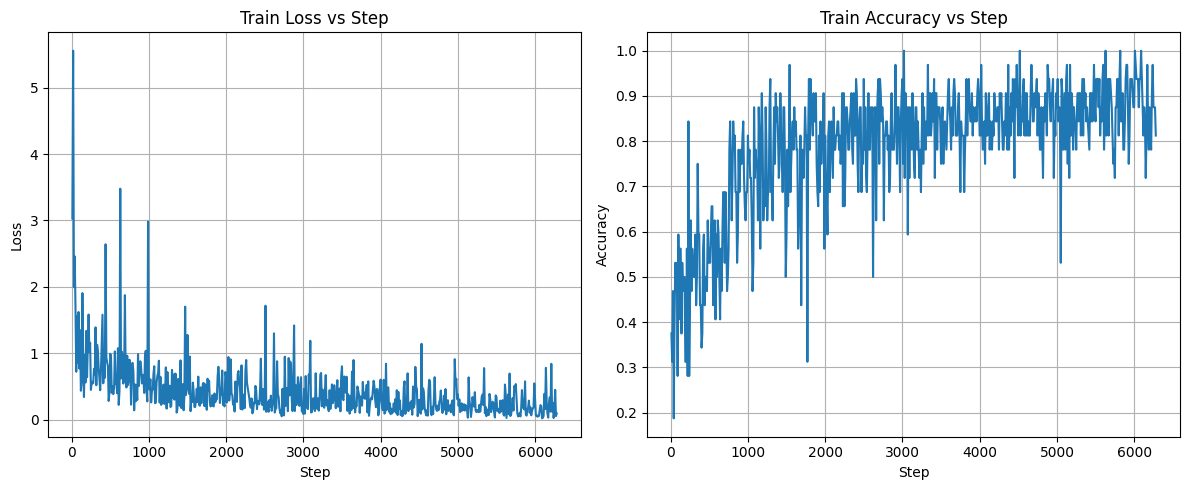

In [4]:
import os
import pandas as pd
import glob
import matplotlib.pyplot as plt

log_dir = "logs/deep_cnn_highway"
versions = sorted(glob.glob(os.path.join(log_dir, "version_*")))
if len(versions) == 0:
    raise RuntimeError("No version_x folders found in logs directory!")
latest_version = versions[-1]
metrics_file = os.path.join(latest_version, "metrics.csv")
df = pd.read_csv(metrics_file)

train_loss = df[["step", "train_loss_step"]].dropna()
train_acc = df[["step", "train_acc_step"]].dropna()

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(train_loss["step"], train_loss["train_loss_step"])
plt.title("Train Loss vs Step")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_acc["step"], train_acc["train_acc_step"])
plt.title("Train Accuracy vs Step")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()